<a href="https://colab.research.google.com/github/upskilling8-ship-it/TASK_05_Ecommerce_Return_Rate_Investigation/blob/notebook/Return_pattern_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/diversified_ecommerce_dataset.csv")

/tmp/ipykernel_733/1287005372.py:3: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/diversified_ecommerce_dataset.csv")


In [ ]:
df.head()

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,P6879,Jacket,Apparel,53.85,5,15,150,S535,35-44,"New York, USA",Male,23.32,Standard,4.49,Yes,56,NaN,NaN,NaN
1,P5132,Camera,Electronics,761.26,10,15,224,S583,25-34,"London, UK",Female,20.88,Overnight,16.11,No,79,NaN,NaN,NaN
2,P2941,Sneakers,Footwear,1756.76,5,8,468,S118,25-34,"Tokyo, Japan",Non-Binary,16.43,Standard,4.93,No,40,NaN,NaN,NaN
3,P8545,Cookbooks,Books,295.24,10,15,25,S104,18-24,"Paris, France",Female,27.49,Standard,1.31,No,93,NaN,NaN,NaN
4,P4594,Camera,Electronics,832.00,10,12,340,S331,55+,"Tokyo, Japan",Male,45.93,Overnight,4.37,No,56,NaN,NaN,NaN


In [ ]:
df.columns

Index(['Product ID', 'Product Name', 'Category', 'Price', 'Discount',
       'Tax Rate', 'Stock Level', 'Supplier ID', 'Customer Age Group',
       'Customer Location', 'Customer Gender', 'Shipping Cost',
       'Shipping Method', 'Return Rate', 'Seasonality', 'Popularity Index',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')

In [ ]:
df[['Category', 'Price', 'Discount', 'Return Rate']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Category     1000000 non-null  object 
 1   Price        1000000 non-null  float64
 2   Discount     1000000 non-null  int64  
 3   Return Rate  1000000 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 30.5+ MB


In [ ]:
category_return = df.groupby('Category')['Return Rate'].mean().sort_values(ascending=False)

category_return

,Return Rate
Category,
Footwear,10.509864
Home Appliances,10.502054
Electronics,10.487290
Books,10.483306
Apparel,10.481973


<Axes: title={'center': 'Average Return Rate by Category'}, xlabel='Category', ylabel='Average Return Rate'>

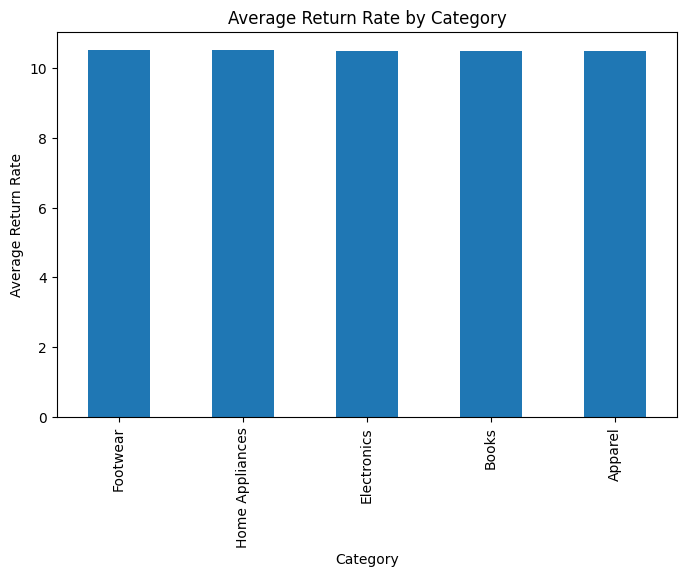

In [ ]:
category_return.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Return Rate by Category',
    xlabel='Category',
    ylabel='Average Return Rate'
)

In [ ]:
price_return = df.groupby('Price')['Return Rate'].mean().sort_values(ascending=False)

price_return

,Return Rate
Price,
882.67,20.00
1517.85,19.99
699.55,19.99
884.09,19.99
664.17,19.99
...,...
965.66,1.01
1103.11,1.01
1022.15,1.00


In [ ]:
df['Price'].describe()

,Price
count,1000000.000000
mean,1005.120742
std,574.451223
min,10.000000
25%,507.860000
50%,1005.430000
75%,1502.310000
max,2000.000000


In [ ]:
df['Price Group'] = pd.cut(
    df['Price'],
    bins=[0, 500, 1000, 1500, 2000],
    labels=['10–500', '501–1000', '1001–1500', '1501–2000']
)

In [ ]:
price_group_return = df.groupby('Price Group', observed=True)['Return Rate'].mean()

price_group_return

,Return Rate
Price Group,
10–500,10.490962
501–1000,10.499528
1001–1500,10.488667
1501–2000,10.492390


<Axes: title={'center': 'Average Return Rate by Price Group'}, xlabel='Price Group', ylabel='Average Return Rate'>

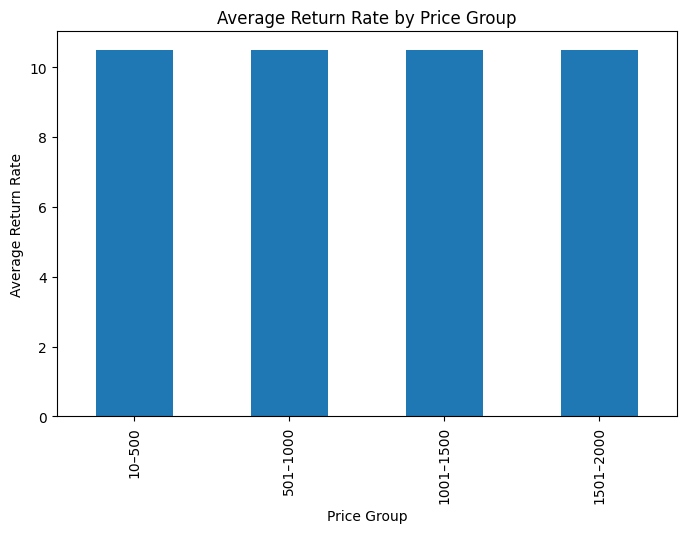

In [ ]:
price_group_return.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Return Rate by Price Group',
    xlabel='Price Group',
    ylabel='Average Return Rate'
)

In [ ]:
df['Shipping Cost'].describe()

,Shipping Cost
count,1000000.000000
mean,24.985224
std,14.431730
min,0.000000
25%,12.490000
50%,24.970000
75%,37.470000
max,50.000000


In [ ]:
df['Shipping Cost Group'] = pd.cut(
    df['Shipping Cost'],
    bins=[-1, 10, 20, 30, 40, 50],
    labels=['0–10', '11–20', '21–30', '31–40', '41–50']
)

In [ ]:
shipping_cost_return = df.groupby(
    'Shipping Cost Group',
    observed=True
)['Return Rate'].mean()

shipping_cost_return

,Return Rate
Shipping Cost Group,
0–10,10.501073
11–20,10.486013
21–30,10.499515
31–40,10.473697
41–50,10.504208


<Axes: title={'center': 'Average Return Rate by Shipping Cost Group'}, xlabel='Shipping Cost Group', ylabel='Average Return Rate'>

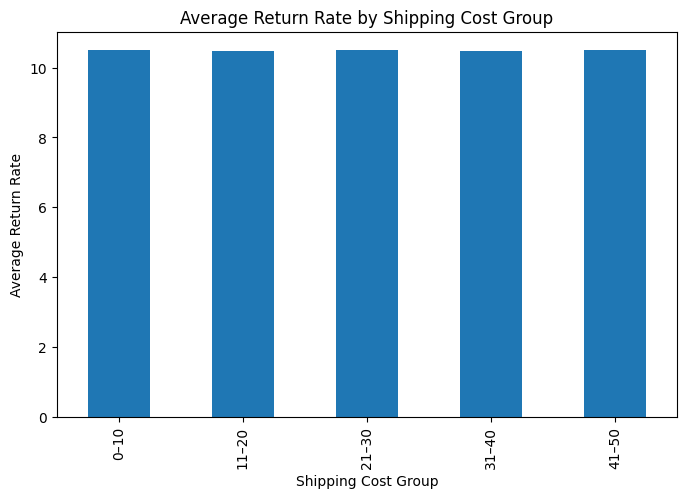

In [ ]:
shipping_cost_return.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Return Rate by Shipping Cost Group',
    xlabel='Shipping Cost Group',
    ylabel='Average Return Rate'
)

In [ ]:
df['Discount'].describe()

,Discount
count,1000000.000000
mean,12.516955
std,8.539929
min,0.000000
25%,5.000000
50%,15.000000
75%,20.000000
max,25.000000


In [ ]:
df['Discount Group'] = pd.cut(
    df['Discount'],
    bins=[-1, 5, 10, 15, 20, 25],
    labels=['0–5%', '6–10%', '11–15%', '16–20%', '21–25%']
)

In [ ]:
discount_return = df.groupby(
    'Discount Group',
    observed=True
)['Return Rate'].mean()

discount_return

,Return Rate
Discount Group,
0–5%,10.493807
6–10%,10.479594
11–15%,10.499905
16–20%,10.498604
21–25%,10.491673


<Axes: title={'center': 'Average Return Rate by Discount Group'}, xlabel='Discount Group', ylabel='Average Return Rate'>

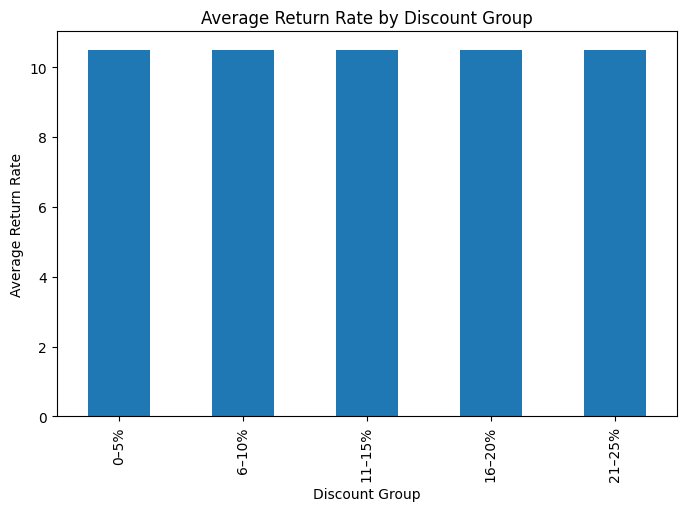

In [ ]:
discount_return.plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Return Rate by Discount Group',
    xlabel='Discount Group',
    ylabel='Average Return Rate'
)

<Axes: title={'center': 'Box Plot of Return Rate'}>

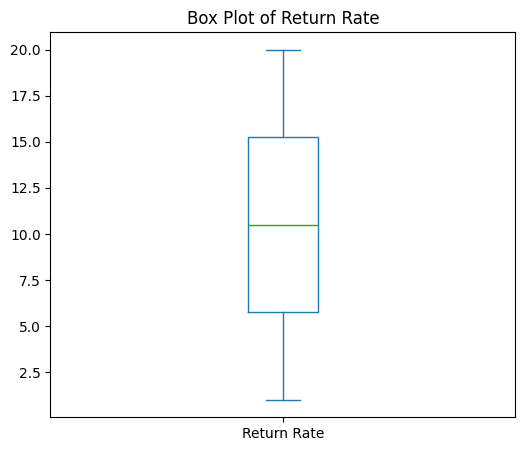

In [ ]:
df['Return Rate'].plot(
    kind='box',
    figsize=(6, 5),
    title='Box Plot of Return Rate'
)

In [ ]:
Q1 = df['Return Rate'].quantile(0.25)
Q3 = df['Return Rate'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5.74
Q3: 15.25
IQR: 9.51
Lower Bound: -8.525
Upper Bound: 29.515


In [ ]:
return_outliers = df[df['Return Rate'] > upper_bound]

print("Number of Return Rate outliers:", len(return_outliers))

Number of Return Rate outliers: 0


<Axes: title={'center': 'Box Plot of Price'}>

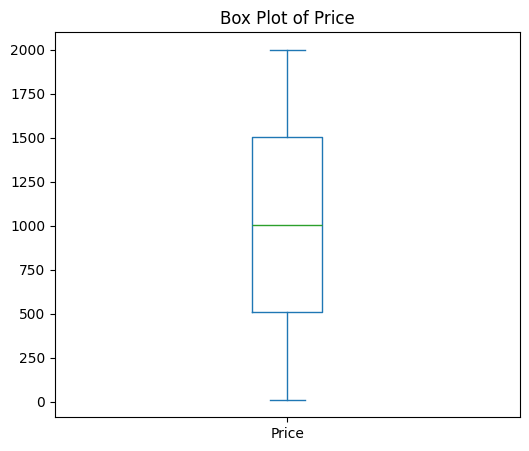

In [ ]:
df['Price'].plot(
    kind='box',
    figsize=(6, 5),
    title='Box Plot of Price'
)

In [ ]:
Q1_price = df['Price'].quantile(0.25)
Q3_price = df['Price'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)
print("Lower Bound:", lower_price)
print("Upper Bound:", upper_price)

Q1: 507.86
Q3: 1502.31
IQR: 994.4499999999999
Lower Bound: -983.8149999999999
Upper Bound: 2993.9849999999997


In [ ]:
price_outliers = df[df['Price'] > upper_price]

print("Number of Price outliers:", len(price_outliers))

Number of Price outliers: 0


<Axes: title={'center': 'Box Plot of Shipping Cost'}>

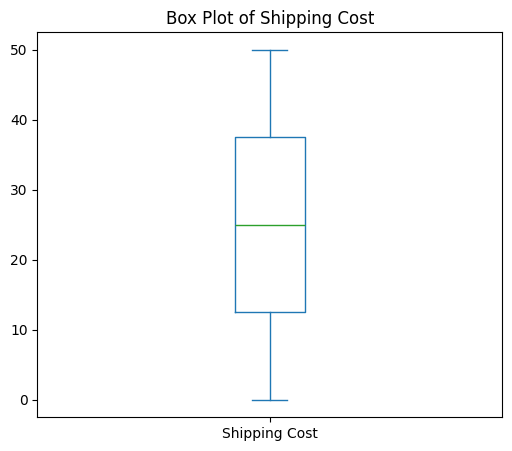

In [ ]:
df['Shipping Cost'].plot(
    kind='box',
    figsize=(6, 5),
    title='Box Plot of Shipping Cost'
)

In [ ]:
Q1_shipping = df['Shipping Cost'].quantile(0.25)
Q3_shipping = df['Shipping Cost'].quantile(0.75)

IQR_shipping = Q3_shipping - Q1_shipping

lower_shipping = Q1_shipping - 1.5 * IQR_shipping
upper_shipping = Q3_shipping + 1.5 * IQR_shipping

print("Q1:", Q1_shipping)
print("Q3:", Q3_shipping)
print("IQR:", IQR_shipping)
print("Lower Bound:", lower_shipping)
print("Upper Bound:", upper_shipping)

Q1: 12.49
Q3: 37.47
IQR: 24.979999999999997
Lower Bound: -24.979999999999997
Upper Bound: 74.94


In [ ]:
shipping_outliers = df[df['Shipping Cost'] > upper_shipping]

print("Number of Shipping Cost outliers:", len(shipping_outliers))

Number of Shipping Cost outliers: 0


<Axes: title={'center': 'Box Plot of Discount'}>

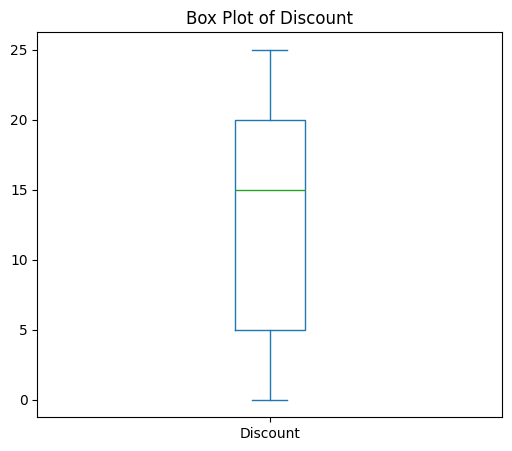

In [ ]:
df['Discount'].plot(
    kind='box',
    figsize=(6, 5),
    title='Box Plot of Discount'
)

In [ ]:
Q1_discount = df['Discount'].quantile(0.25)
Q3_discount = df['Discount'].quantile(0.75)

IQR_discount = Q3_discount - Q1_discount

lower_discount = Q1_discount - 1.5 * IQR_discount
upper_discount = Q3_discount + 1.5 * IQR_discount

print("Q1:", Q1_discount)
print("Q3:", Q3_discount)
print("IQR:", IQR_discount)
print("Lower Bound:", lower_discount)
print("Upper Bound:", upper_discount)

Q1: 5.0
Q3: 20.0
IQR: 15.0
Lower Bound: -17.5
Upper Bound: 42.5


In [ ]:
discount_outliers = df[df['Discount'] > upper_discount]

print("Number of Discount outliers:", len(discount_outliers))

Number of Discount outliers: 0


In [ ]:
from scipy.stats import f_oneway

group1 = df[df['Discount Group'] == '0–5%']['Return Rate']
group2 = df[df['Discount Group'] == '6–10%']['Return Rate']
group3 = df[df['Discount Group'] == '11–15%']['Return Rate']
group4 = df[df['Discount Group'] == '16–20%']['Return Rate']
group5 = df[df['Discount Group'] == '21–25%']['Return Rate']

f_stat, p_value = f_oneway(
    group1, group2, group3, group4, group5
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.3630026322081466
p-value: 0.8351067605636988


In [ ]:
print("Hypothesis Testing Results")
print("--------------------------")
print("Test: One-Way ANOVA")
print("F-statistic:", f_stat)
print("p-value:", p_value)
print("Significance level: 0.05")

Hypothesis Testing Results
--------------------------
Test: One-Way ANOVA
F-statistic: 0.3630026322081466
p-value: 0.8351067605636988
Significance level: 0.05


In [ ]:
df['Return Rate'].median()

10.48

In [ ]:
df['Return Segment'] = df['Return Rate'].apply(
    lambda x: 'High-return' if x > 10.48 else 'Lower-return'
)

df['Return Segment'].value_counts()

,count
Return Segment,
Lower-return,500018
High-return,499982


In [ ]:
df['Discount'].median()

15.0

In [ ]:
df['Discount Segment'] = df['Discount'].apply(
    lambda x: 'Discount-driven' if x > 15 else 'Lower-discount'
)

df['Discount Segment'].value_counts()

,count
Discount Segment,
Lower-discount,665567
Discount-driven,334433


In [ ]:
df['Price'].median()

1005.43

In [ ]:
df['Price Segment'] = df['Price'].apply(
    lambda x: 'Premium' if x > 1005.43 else 'Lower-price'
)

df['Price Segment'].value_counts()

,count
Price Segment,
Lower-price,500005
Premium,499995


In [ ]:
df.groupby('Return Segment')[['Price', 'Discount']].mean()

,Price,Discount
Return Segment,,
High-return,1005.123769,12.514861
Lower-return,1005.117716,12.519049


In [ ]:
df.groupby('Discount Segment')['Return Rate'].mean()

,Return Rate
Discount Segment,
Discount-driven,10.495144
Lower-discount,10.491767


In [ ]:
df.groupby('Price Segment')['Return Rate'].mean()

,Return Rate
Price Segment,
Lower-price,10.496171
Premium,10.489622


In [ ]:
print("PHASE 6 - CUSTOMER SEGMENTATION SUMMARY")
print("----------------------------------------")

print("\nHigh-return vs Lower-return:")
print(df.groupby('Return Segment')[['Price', 'Discount']].mean())

print("\nDiscount-driven vs Lower-discount:")
print(df.groupby('Discount Segment')['Return Rate'].mean())

print("\nPremium vs Lower-price:")
print(df.groupby('Price Segment')['Return Rate'].mean())

PHASE 6 - CUSTOMER SEGMENTATION SUMMARY
----------------------------------------

High-return vs Lower-return:
                      Price   Discount
Return Segment                        
High-return     1005.123769  12.514861
Lower-return    1005.117716  12.519049

Discount-driven vs Lower-discount:
Discount Segment
Discount-driven    10.495144
Lower-discount     10.491767
Name: Return Rate, dtype: float64

Premium vs Lower-price:
Price Segment
Lower-price    10.496171
Premium        10.489622
Name: Return Rate, dtype: float64


In [ ]:
print("PHASE 7 - BUSINESS INSIGHTS")
print("---------------------------")

print("\n1. Factors contributing to returns:")
print("Category, price, shipping cost, and discount show only very small differences in average return rates.")
print("No strong relationship was identified between these factors and return rate.")

print("\n2. Risky categories:")
print("Footwear has the highest average return rate at approximately 10.51%.")
print("However, the differences between categories are very small.")

print("\n3. Delayed delivery:")
print("Delivery Time is not available in the dataset, so its effect on return probability cannot be evaluated.")

print("\n4. Customer groups needing intervention:")
print("Discount-driven, premium, and high-return segments were analyzed.")
print("The differences in return behavior between these segments are very small.")

print("\n5. Recommended actions:")
print("Monitor return rates by category.")
print("Review return reasons where available.")
print("Avoid assuming that higher discounts automatically cause more returns.")
print("Collect delivery-time and customer-level data for deeper analysis.")

PHASE 7 - BUSINESS INSIGHTS
---------------------------

1. Factors contributing to returns:
Category, price, shipping cost, and discount show only very small differences in average return rates.
No strong relationship was identified between these factors and return rate.

2. Risky categories:
Footwear has the highest average return rate at approximately 10.51%.
However, the differences between categories are very small.

3. Delayed delivery:
Delivery Time is not available in the dataset, so its effect on return probability cannot be evaluated.

4. Customer groups needing intervention:
Discount-driven, premium, and high-return segments were analyzed.
The differences in return behavior between these segments are very small.

5. Recommended actions:
Monitor return rates by category.
Review return reasons where available.
Avoid assuming that higher discounts automatically cause more returns.
Collect delivery-time and customer-level data for deeper analysis.
